# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Author: Aaron Thomas

## Table of Contents

<ol>
    <li>Introduction</li>
        <ol>
            <li>Project Overview</li>
            <li>Objectives</li>
        </ol>
    <li>Data Loading and Inspection</li>
        <ol>
            <li>Data Source</li>
            <li>Importing Libraries</li>
            <li>Loading the Dataset</li>
            <li>Column Descriptions</li>
        </ol>
    <li>Data Cleaning and Preprocessing</li>
        <ol>
            <li>Handling Missing Values</li>
            <li>Data Type Conversions</li>
        </ol>
    <li>Exploratory Data Analysis</li>
        <ol>
            <li>Univariate Analysis</li>
            <li>Bivariate Analysis</li>
            <li>Multivariate Analysis</li>
        </ol>
    <li>Conclusion</li>
        <ol>
            <li>Key Findings</li>
            <li>Business Implications</li>
            <li>Next Steps</li>
</ol>

## Introduction

### 1.1) Project Overview

This project focuses on analyzing customer churn in a telecommunications company. The term 'churn' is the loss of customers who discontinue their use of a product/service, impacting revenue and long-term business growth. 

The goal of this notebook is to perform exploratory data analysis (EDA) to understand patterns and factors contributing to customer churn, which will inform the development of predictive models in subsequent stages.

### 1.2) Objectives

The main objectives of this exploratory data analysis are:
- Understanding the structure and characteristics of the dataset.
- Identifying key features that may influence customer churn.
- Detecting any data quality issues such as missing values or outliers.

Additionally, the following questions will be explored:
1. Who is most likely to churn? (e.g., demographics, service usage)
2. What factors contribute most to customer churn? (e.g., contract type, monthly charges)
3. What is the relationship between pricing and churn? (e.g., monthly charges, total charges)





## 2. Data Loading and Inspection

### 2.1) Data Source

The dataset used in this project is the "Telco Customer Churn" dataset, which is publicly available on Kaggle. It contains information about customers of a telecommunications company, including their demographics, account information, and whether they have churned.

### 2.2) Importing Libraries

The following libraries will be imported for data manipulation, visualization, and analysis:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2.3) Loading the Dataset

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.4) Column Descriptions

The following columns are present in the dataset:
- `customerID`: Unique identifier for each customer.
- `gender`: Gender
- `SeniorCitizen`: Whether the customer is a senior citizen (1, 0)
- `Partner`: Whether the customer has a partner (Yes, No)
- `Dependents`: Whether the customer has dependents (Yes, No)
- `tenure`: Number of months the customer has stayed with the company
- `PhoneService`: Whether the customer has phone service (Yes, No)
- `MultipleLines`: Whether the customer has multiple lines (Yes, No, No phone service)
- `InternetService`: Customer’s internet service provider (DSL, Fiber optic, No)
- `OnlineSecurity`: Whether the customer has online security (Yes, No, No internet service)
- `OnlineBackup`: Whether the customer has online backup (Yes, No, No internet service)
- `DeviceProtection`: Whether the customer has device protection (Yes, No, No internet service)
- `TechSupport`: Whether the customer has tech support (Yes, No, No internet service)
- `StreamingTV`: Whether the customer has streaming TV (Yes, No, No internet service
- `StreamingMovies`: Whether the customer has streaming movies (Yes, No, No internet service)
- `Contract`: The contract term of the customer (Month-to-month, One year, Two year)
- `PaperlessBilling`: Whether the customer has paperless billing (Yes, No)
- `PaymentMethod`: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- `MonthlyCharges`: The amount charged to the customer monthly
- `TotalCharges`: The total amount charged to the customer
- `Churn`: Whether the customer churned (Yes or No)



## 3. Data Cleaning and Preprocessing

The purpose of this section is to clean and preprocess the dataset to ensure it is ready for analysis and modeling. This includes handling missing values, converting data types, and addressing any inconsistencies in the data.

### 3.1) Handling Missing Values

To check for missing values in the dataset, the following code will be used:

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Based on the results above, there are no missing values in the dataset, so no further action is needed to handle missing data.

*Note: In section 3.2, we will convert the `TotalCharges` column to a numeric data type, which may reveal any non-numeric values that could be considered as missing values.*

### 3.2) Data Type Conversions

To examine the data types of each column, the following code will be used:

In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Looking at the data types above, the following changes will be made:
- `TotalCharges` will be converted to a numeric data type, as it is currently an object due to some non-numeric values (e.g., spaces).
- `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, and `Churn` will be converted to binary types, where 'Yes' will be mapped to 1 and 'No' will be mapped to 0. For gender, male will be mapped to 1 and female will be mapped to 0. 
- `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, and `PaymentMethod` will be converted to categorical data types.

The `TotalCharges` column contains empty strings for new customers (tenure=0) that have been recorded in the CSV as blank values. These need to be replaced with 0 before converting to numeric to avoid NaN values. The following code will be used to convert `TotalCharges` to a numeric data type:

In [5]:
df['TotalCharges'] = df['TotalCharges'].str.strip() # Remove leading/trailing spaces
df['TotalCharges'] = df['TotalCharges'].replace('', '0') # Replace empty strings with 0 (new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

The following code will be used to convert the specified columns to binary and categorical data types:

In [6]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

*Note: The `SeniorCitizen` column is already in a binary format (1 for senior citizens and 0 for non-senior citizens), so no changes are needed for this column.*

The following code will be used to perform these conversions:

In [7]:
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaymentMethod']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.dtypes

customerID            object
gender                 int64
SeniorCitizen          int64
Partner                int64
Dependents             int64
tenure                 int64
PhoneService           int64
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling       int64
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
dtype: object

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## 4. Exploratory Data Analysis

### 4.1) Univariate Analysis

#### Monthly Charges Distribution

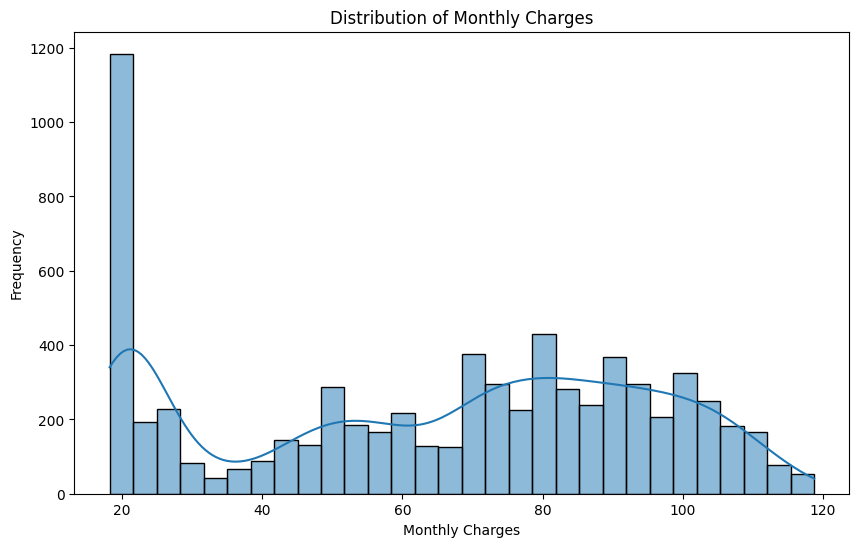

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

Based on the results above, the following observations can be made:
- The MonthlyCharges variable shows a multimodal distribution, indicating that there are distinct groups of customers with different monthly charge levels.
- The distribution seems to be slightly right-skewed, suggesting the presence of customers with different pricing levels.

#### Total Charges Distribution

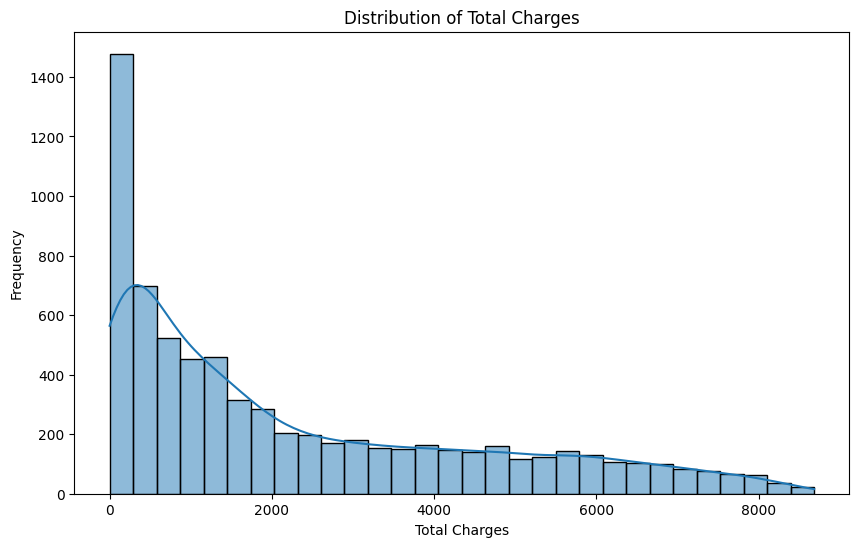

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

Based on the results above, the following observations can be made:
- The distribution is also right-skewed, similar to monthly charges, indicating that most customers have lower total charges, while a smaller number of customers have higher total charges.

#### Tenure Distribution

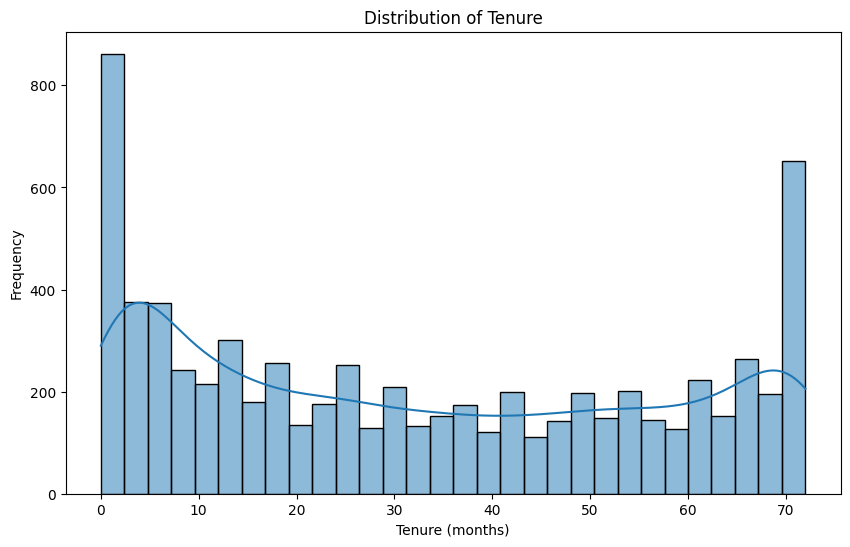

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.show()

Based on the results above, the following observations can be made:
- The distribution is bimodal (two peaks), suggesting that there are two strong and distinct groups of customers: those with short tenure (e.g., 0-5 months) and those with long tenure (e.g., 65-70 months).

#### Churn Distribution

The purpose of this analysis is to examine the distribution of the target variable, `Churn`, to understand the proportion of customers who have churned versus those who have not. The following code will be used to visualize the distribution of `Churn`:

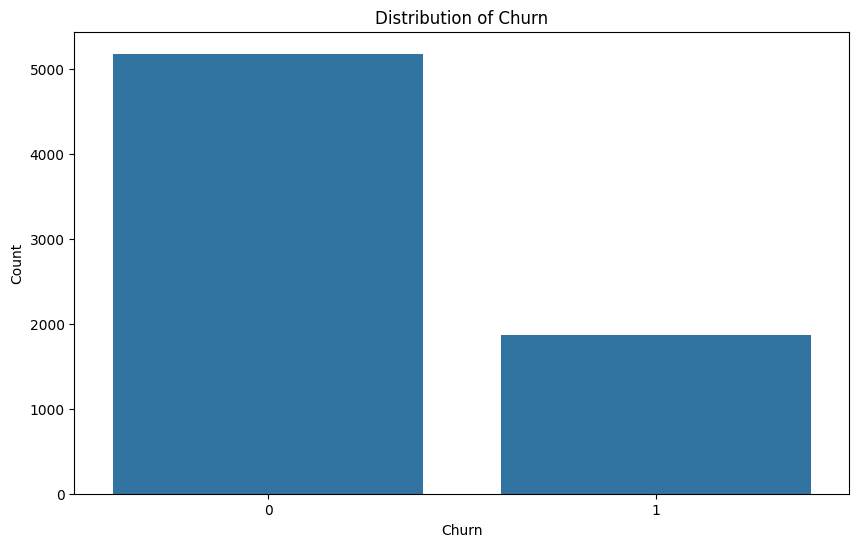

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

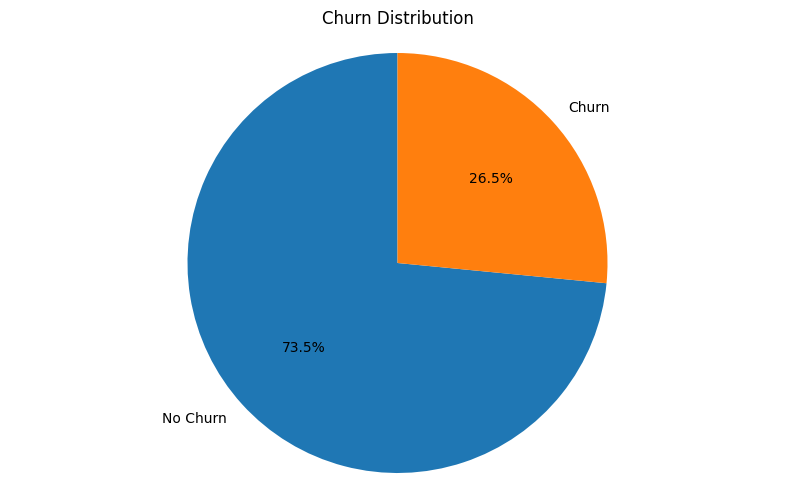

In [26]:
plt.figure(figsize=(10, 6))
plt.pie(df['Churn'].value_counts(), labels=['No Churn', 'Churn'], autopct='%1.1f%%', startangle=90)
plt.title('Churn Distribution')
plt.axis('equal')
plt.show()

Based on the results above, it can be observed that there are more customers who have not churned (No) than those who have churned (Yes). The pie chart shows that 26.5% of customers have churned, while 73.5% have not. This indicates that the dataset is imbalanced, which may have implications for modeling and will need to be addressed in later stages of the project through SMOTE.

#### Gender Distribution

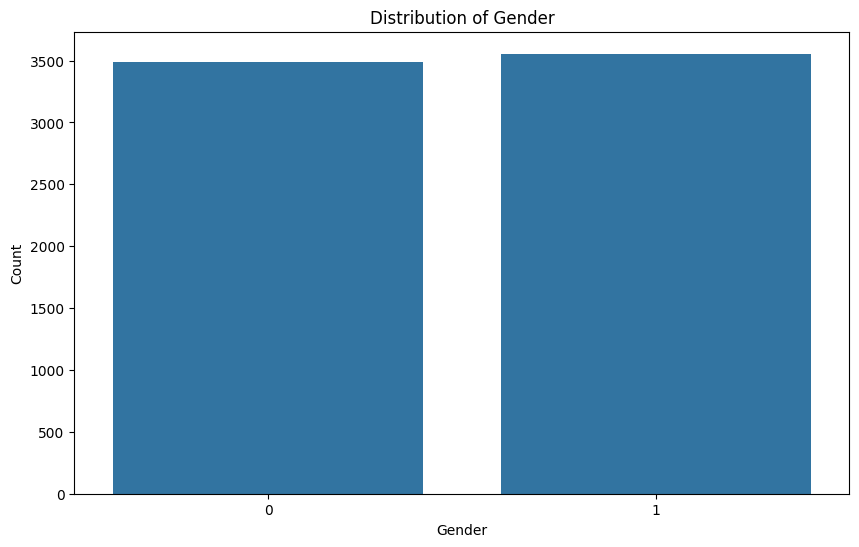

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=df)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Based on the results above, the following observations can be made:
- The distribution between genders is relatively balanced, with a slightly higher number of male customers compared to female customers.

#### Senior Citizen Distribution

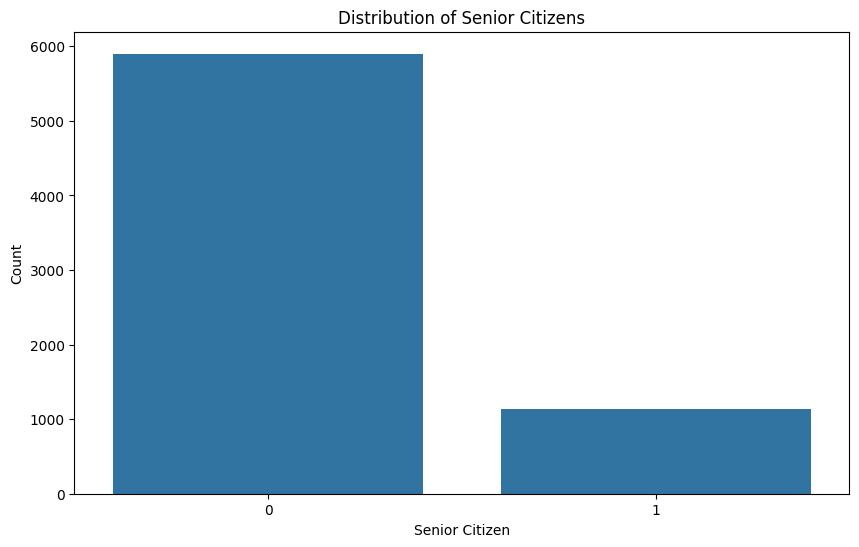

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x='SeniorCitizen', data=df)
plt.title('Distribution of Senior Citizens')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.show()

Based on the results above, it can be observed that there are more non-senior citizens (0) than senior citizens (1) in the dataset.

#### Payment Method Distribution

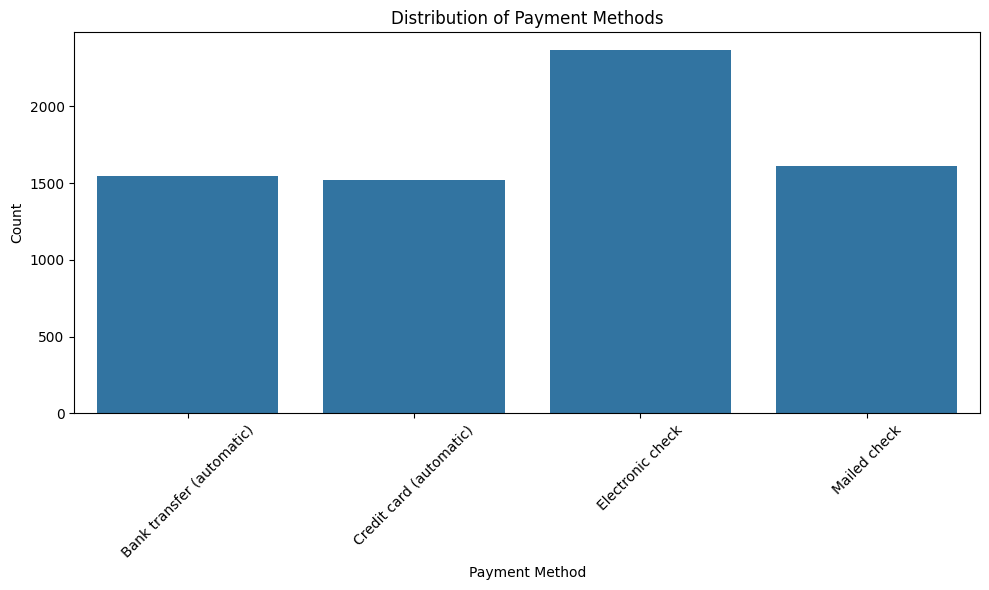

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', data=df)
plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the results above, the following observations can be made:
- Most customers use electronic check as their payment method, followed mailed check, bank transfer (automatic), and credit card (automatic).

#### Internet Service Distribution

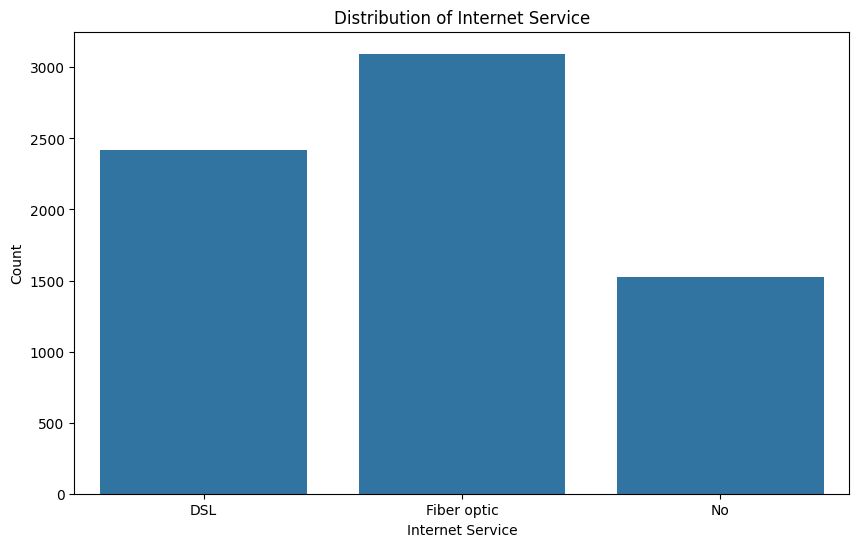

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x="InternetService", data=df)
plt.title('Distribution of Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

Based on the results above, it is observed that the most common internet service among customers is Fiber optic.

### 4.2) Bivariate Analysis

#### Tenure vs Churn

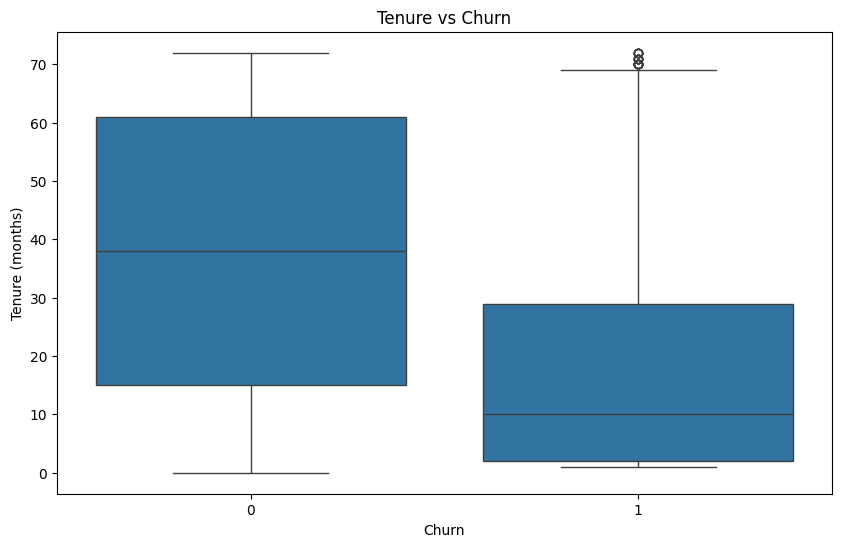

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()

Based on the results above, the following observations can be made:
- Customers who have churned (Yes) tend to have a shorter tenure (<10-30 months), while those who did not churn (No) tend to have longer tenure (20-60 months).
- This suggests that customers with shorter tenure are likely newer customers. This also suggests that it is crucial to focus on retaining newer customers to prevent churn. 

#### Monthly Charges vs Churn

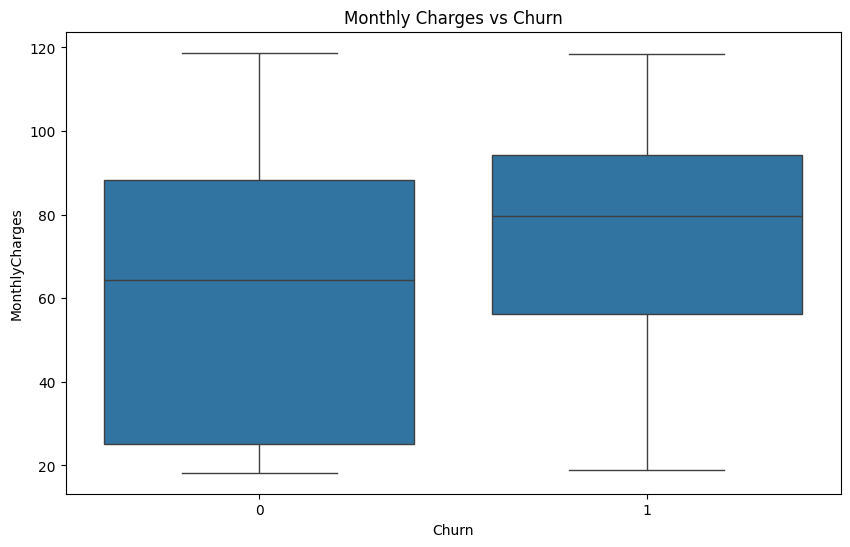

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()


Based on the results above, the following observations can be made:
- Customers who churned have higher monthly charges compared to those who did not churn. This suggests that higher monthly charges may be a contributing factor to customer churn.
- The median monthly charges for customers who churned is around $80, while for those who did not churn, it is around $60. This also indicates that customers with higher monthly charges are more likely to churn.

#### Total Charges vs Churn

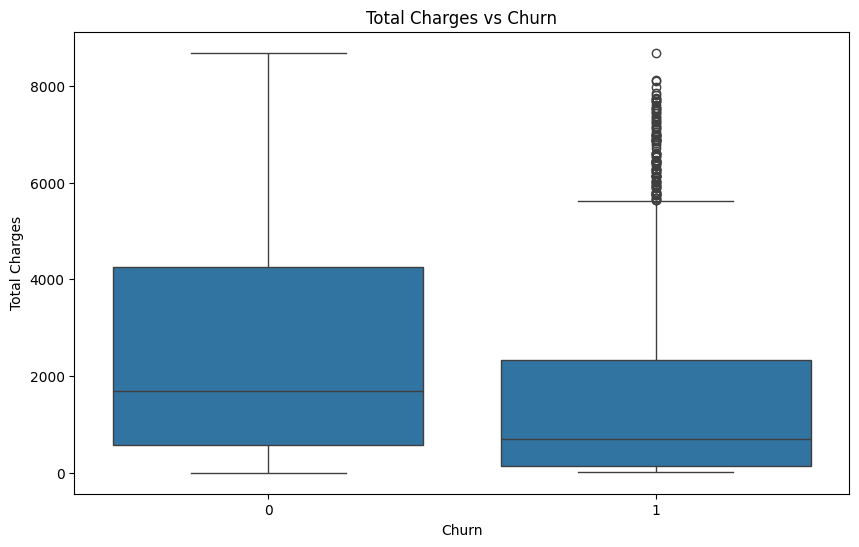

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y="TotalCharges", data=df)
plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

Based on the results above, the following observations can be made:
- The total charges for customers who churned are lower (<$2000) compared to those who did not churn. A reason why churned customers have lower total charges could be due to them having shorter tenure. 
- The outliers for total charges among churned customers indicates that there are few customers who have churned but have high total charges, which could be due to them having a long tenure before eventually churning.

#### Monthly Charges by Contract

The purpose of this analysis is to examine the relationship between monthly charges and contract type to understand how different contract types may influence monthly charges and potentially contribute to customer churn. The following code will be used to visualize the relationship between `MonthlyCharges` and `Contract`:

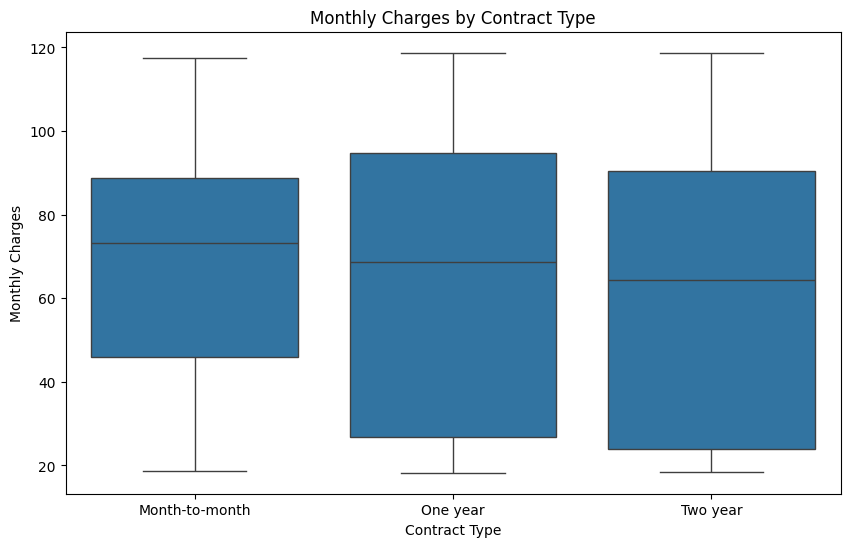

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Contract', y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")
plt.show()

Based on the results above, the following observations can be made:
- The median monthly charge for customers on two-year contracts is lower than those on month-to-month and one-year contracts.
- Higher monthly charges in customers on month-to-month contracts may play a factor in churn, while those on two-year contracts with low monthly charges are less likely to churn.
- It is likely that discounted plans or bundled services could impact those on two-year contracts, which may contribute to lower monthly charges and reduced likelihood of churn.

#### Contract Type by Churn

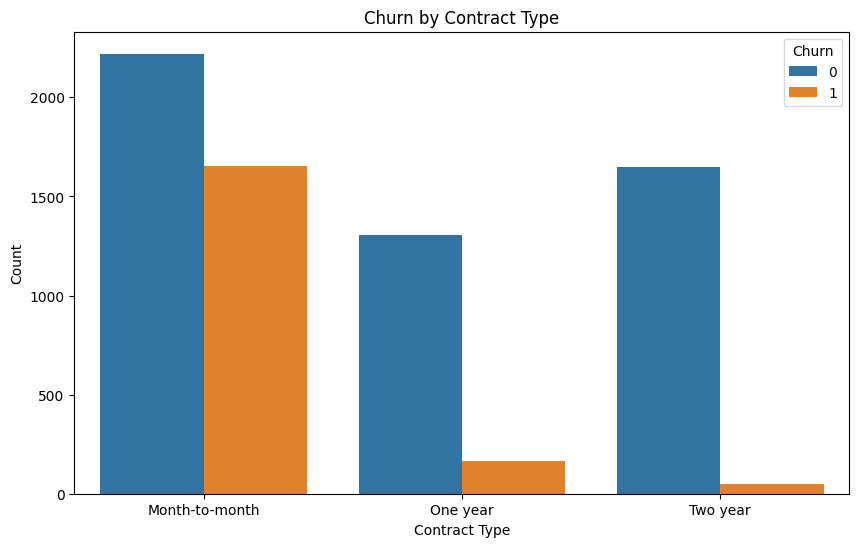

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

Based on the results above, the following observations can be made:
- Customers on month-to-month contracts have a higher likelihood of churn compared to those on one-year and two-year contracts.
- In addition, the majority of customers who have not churned are also on month-to-month contracts, followed by two-year and one-year contracts. A reason for this could be that customers on month-to-month contracts have more flexibility to leave, while those on longer-term contracts may have incentives to stay (e.g., lower monthly charges, bundled services). This suggests that contract type is an important factor to consider when analyzing customer churn.

#### Internet Service by Churn

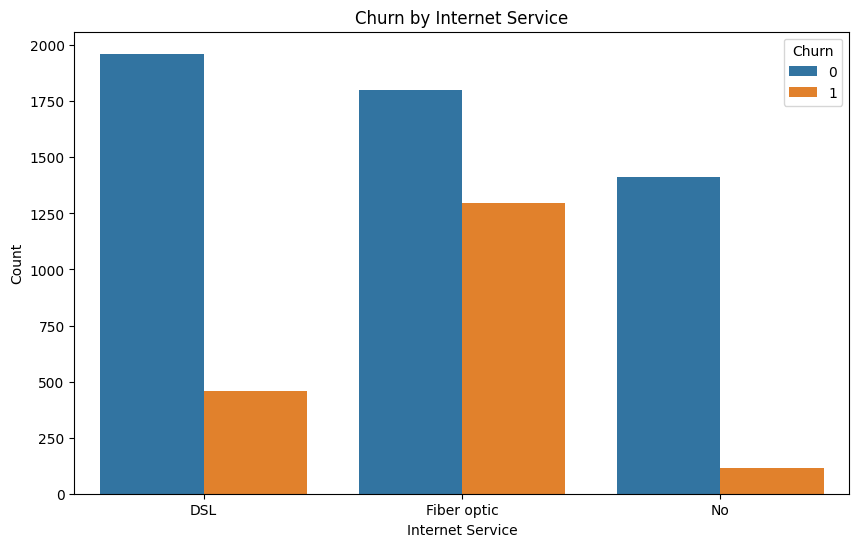

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

Based on the results above, the following observations can be made:
- Customers with Fiber optic internet service have higher churn compared to those with DSL or no internet service. A reason could be that customers with fiber optic service may have higher monthly charges, which could contribute to their decision to churn.

#### Payment Method by Churn

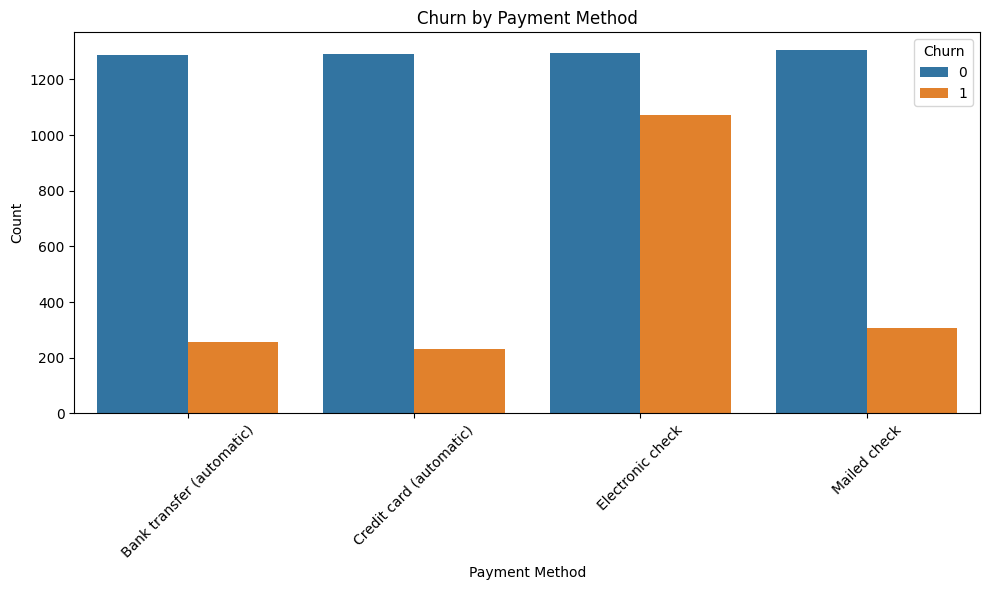

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the results above, the following observations can be made:
- Customers who pay with electronic check have higher churn. This could be because those with less commitment to the company may prefer electronic check, which is a more flexible payment method, while those with more commitment may choose other methods (e.g., bank transfer or credit card).

### 4.3) Multivariate Analysis

#### Correlation Matrix

The purpose of this analysis is to examine the correlations between numerical features in the dataset to identify any strong relationships that may exist between them. This can help in understanding which features may be related to each other and potentially to the target variable, `Churn`. The following code will be used to create a correlation matrix:

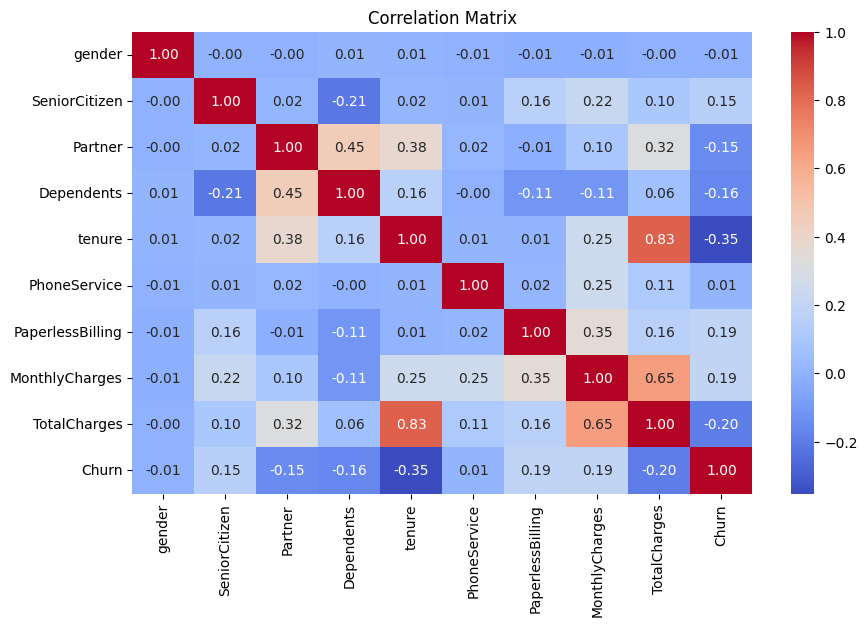

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Based on the matrix above, the following observations can be made:
- `tenure` and `TotalCharges` have a strong positive correlation (0.83), indicating that customers with longer tenure tend to have higher total charges, which makes sense as they have been billed for more months.
- `MonthlyCharges` and `Churn` have a weak positive correlation (0.19), suggesting that higher monthly charges may be associated with a higher likelihood of churn, but the relationship is not very strong.
- `Dependents` and `Partner` have a moderate positive correlation (0.45), indicating that customers with dependents are more likely to have a partner, which could be relevant for understanding customer demographics and their relationship to churn.


#### Monthly Charges By Contract Type and Churn Status

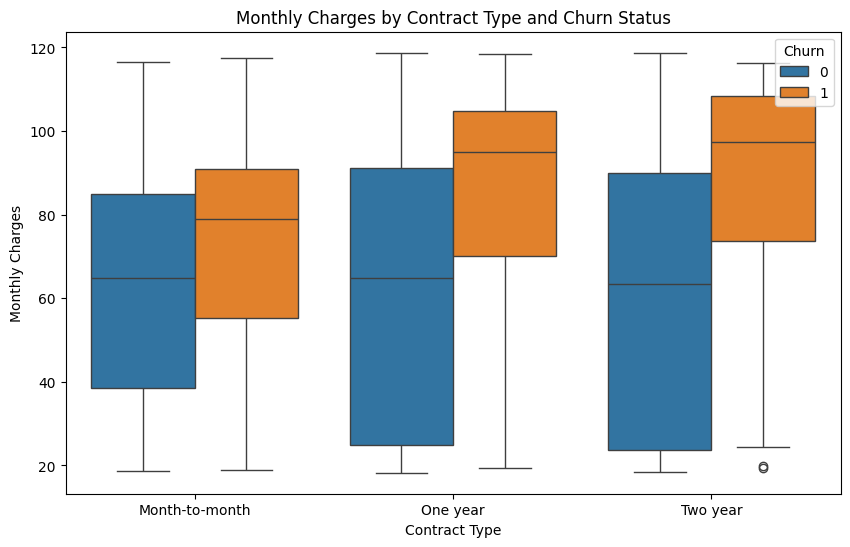

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Monthly Charges by Contract Type and Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn', loc='upper right')
plt.show()

Based on the results above, the following observations can be made:
- The churned customers for each contract type have higher median monthly charges compared to those who did not churn, suggesting that higher monthly charges may be a contributing factor to customer churn.

#### Total Charges By Contract Type and Churn Status

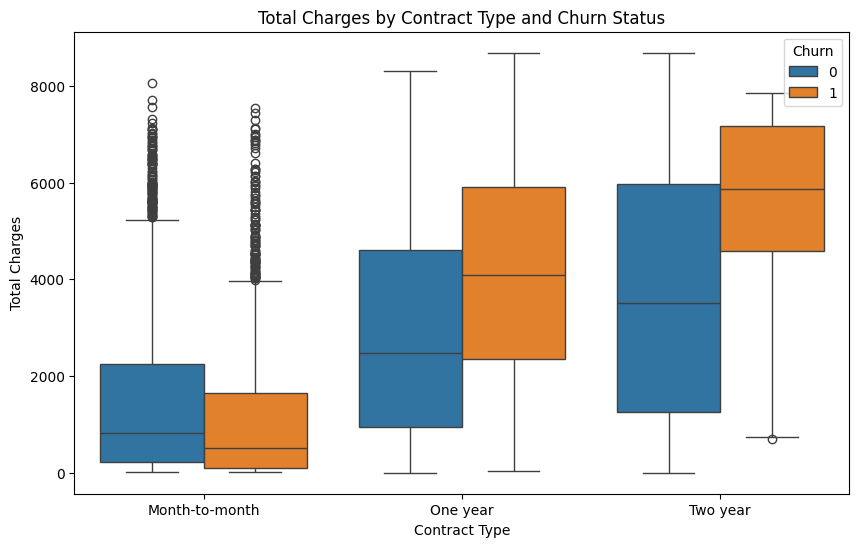

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Contract', y='TotalCharges', hue='Churn', data=df)
plt.title('Total Charges by Contract Type and Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Total Charges')
plt.legend(title='Churn', loc='upper right')
plt.show()

Based on the results above, the following observations can be made:
- In the month-to-month contract type, the median total charges for churned customers is lower than those who did not churn, which could be due to the fact that they have shorter tenure.
- In the one-year and two-year contract types, the median total charges for churned customers is higher than those who did not churn, which could be due to the fact that they have longer tenure before eventually churning.

### 5) Conclusion

#### 5.1) Key Findings
- Customers with shorter tenure are more likely to churn, indicating that newer customers are more likely to leave the service.
- Higher monthly charges are associated with a higher likelihood of churn, suggesting that pricing may be a factor in customer retention.
- Customers on month-to-month contracts with higher monthly charges are more likely to churn, while those on two-year contracts with lower monthly charges are less likely to churn.
- Customers with Fiber optic internet service have a higher churn rate compared to those with DSL or no internet service.
- Customers paying with electronic check have a higher churn rate compared to those using other payment methods.

#### 5.2) Business Implications
The findings from this exploratory data analysis have several implications for the telecommunications company:
- The company should focus on retaining newer customers, as they are more likely to churn. This could involve offering incentives or personalized support to new customers to encourage them to stay.
- The company should consider reviewing its pricing strategy, especially for customers on month-to-month contracts, to reduce the likelihood of churn. This could involve offering discounts or bundled services to make the monthly charges more attractive.
- The company should investigate why fiber optic internet service customers have a higher churn rate and consider strategies to improve customer satisfaction for this group, such as improving service quality or offering competitive pricing.
- The company should also investigate why customers paying with electronic check have a higher churn rate and consider strategies to encourage these customers to switch to more stable payment methods, such as bank transfer or credit card, which may indicate a stronger commitment to the company.

#### 5.3) Next Steps
The next steps in this project will involve:
- Feature engineering to create new features that may help in predicting customer churn. In addition, columns like `customerID` will be dropped as they do not provide predictive value for the target variable `Churn`.
- Addressing the class imbalance in the target variable `Churn` using techniques such as SMOTE. This will be applied to the training data set to ensure that the predictive models are not biased towards the majority class.
- Building predictive models to identify customers at risk of churning based on the insights gained from this exploratory data analysis.